# Week 05 · Frequency Domain Processing
**Course:** Computer Vision (BCSE2022)
**Instructor:** Bùi Huy Kiên
**Prepared:** 2026-07-15


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Hiểu biến đổi Fourier 2-D (DFT) và ý nghĩa của phổ biên độ (magnitude spectrum) / pha (phase).
- Hiển thị và đọc phổ tần số của ảnh; hiểu vì sao cần dịch tâm (fftshift) và nén dải động (log).
- Thiết kế và áp dụng bộ lọc thông thấp Ideal / Butterworth / Gaussian trong miền tần số; nhận biết hiện tượng ringing.
- Thiết kế bộ lọc thông cao tương ứng và dùng để làm sắc nét ảnh (high-frequency emphasis).
- Nắm quan hệ giữa lọc miền không gian (tuần 04) và lọc miền tần số.


**Hướng dẫn:**
- Ảnh mẫu lấy từ bộ ảnh sách Gonzalez & Woods (DIP 3rd ed.) trong thư mục `Gonzalez_images/` ở gốc repo.
- Mỗi cell hiển thị ảnh dùng `matplotlib`.
- Sử dụng các thư viện: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


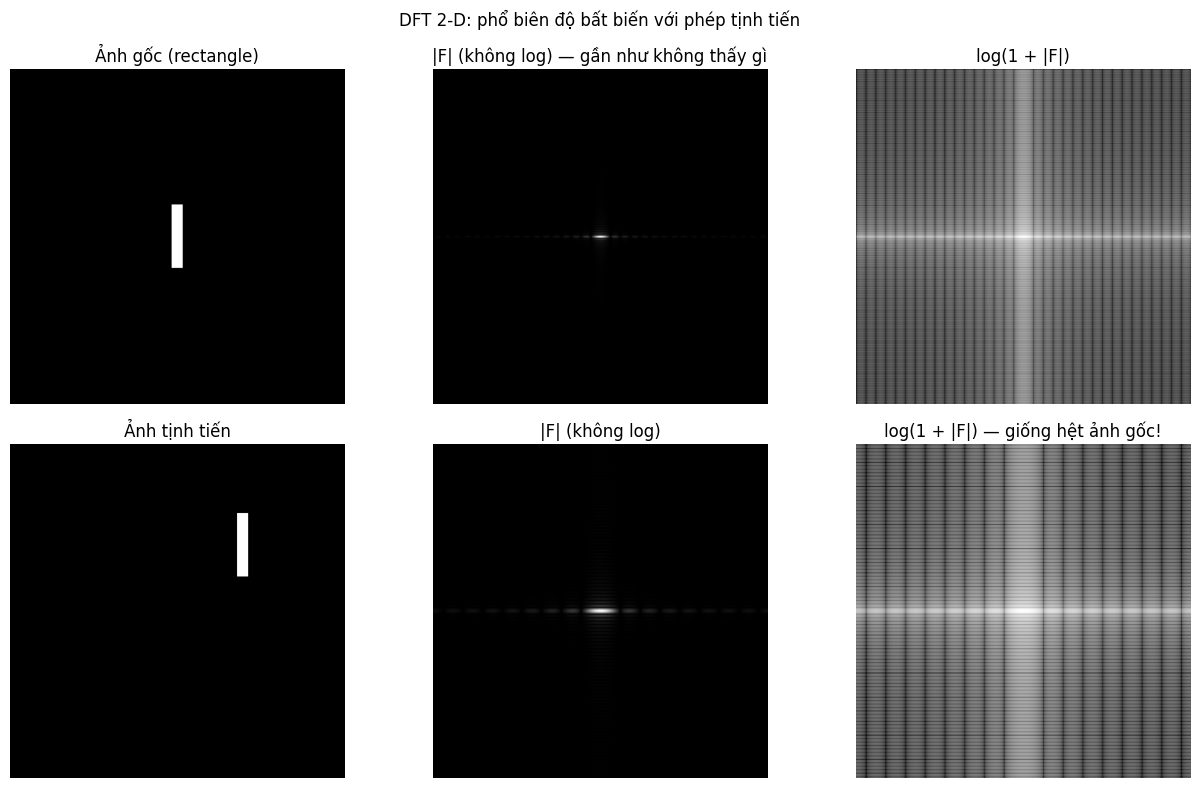

In [1]:
## Ví dụ 1: Biến đổi Fourier 2-D và phổ biên độ
# - Tính DFT bằng np.fft.fft2, dịch tâm phổ bằng fftshift.
# - Phổ có dải động rất lớn -> dùng log(1 + |F|) để hiển thị.
# - Tính chất dịch chuyển: ảnh tịnh tiến có CÙNG phổ biên độ (chỉ khác pha).

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0424(a)(rectangle).tif").convert("L"))
img_trans = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0425(a)(translated_rectangle).tif").convert("L"))

def spectrum(f):
    """Trả về phổ biên độ (đã dịch tâm) và bản nén log để hiển thị."""
    F = np.fft.fftshift(np.fft.fft2(f.astype(np.float64)))
    mag = np.abs(F)
    return mag, np.log1p(mag)

mag1, logmag1 = spectrum(img)
mag2, logmag2 = spectrum(img_trans)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0, 0].imshow(img, cmap="gray"); axes[0, 0].set_title("Ảnh gốc (rectangle)")
axes[0, 1].imshow(mag1, cmap="gray"); axes[0, 1].set_title("|F| (không log) — gần như không thấy gì")
axes[0, 2].imshow(logmag1, cmap="gray"); axes[0, 2].set_title("log(1 + |F|)")
axes[1, 0].imshow(img_trans, cmap="gray"); axes[1, 0].set_title("Ảnh tịnh tiến")
axes[1, 1].imshow(mag2, cmap="gray"); axes[1, 1].set_title("|F| (không log)")
axes[1, 2].imshow(logmag2, cmap="gray"); axes[1, 2].set_title("log(1 + |F|) — giống hệt ảnh gốc!")
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("DFT 2-D: phổ biên độ bất biến với phép tịnh tiến")
plt.tight_layout()
plt.show()


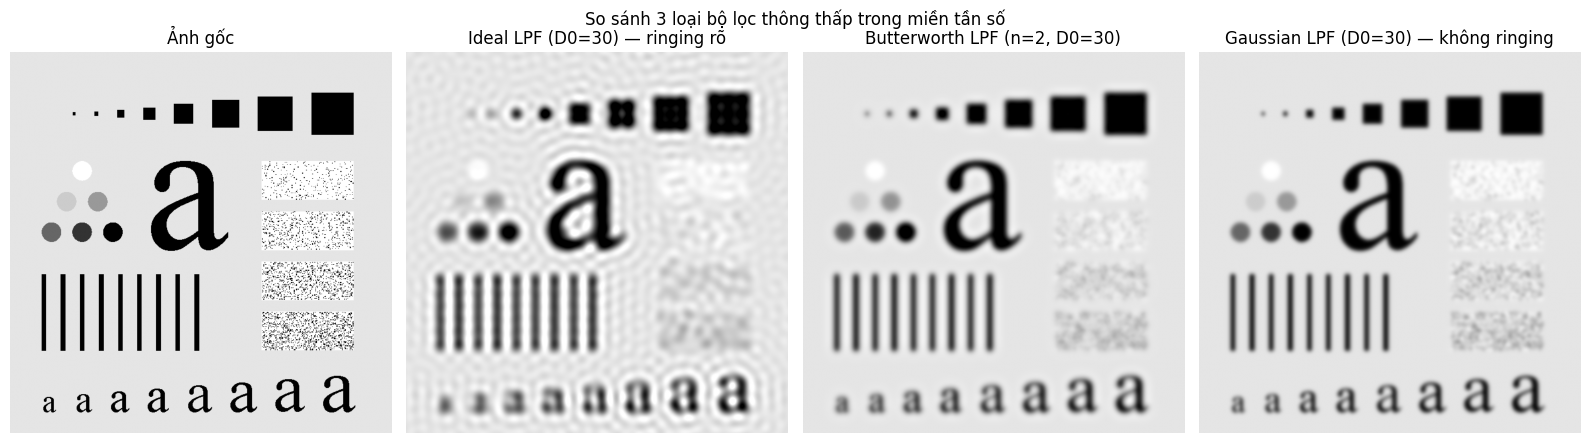

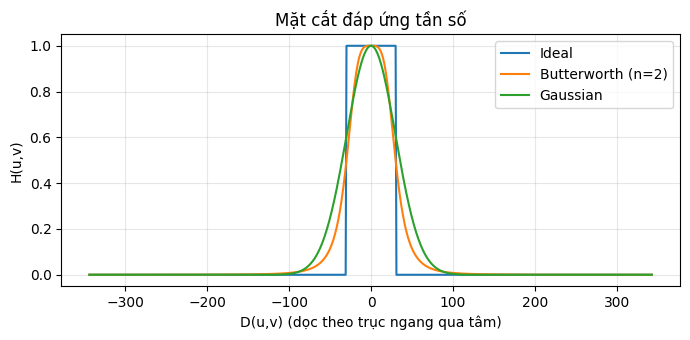

In [2]:
## Ví dụ 2: Lọc thông thấp trong miền tần số — Ideal vs Butterworth vs Gaussian
# Quy trình: F = DFT(f) -> G = H * F -> g = IDFT(G).
# Cùng tần số cắt D0, quan sát hiện tượng RINGING của bộ lọc Ideal.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif").convert("L"))
M, N = img.shape

def dist_grid(M, N):
    """Ma trận khoảng cách D(u,v) tới tâm phổ."""
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    V, U = np.meshgrid(v, u)
    return np.sqrt(U**2 + V**2)

def apply_freq_filter(img, H):
    """Lọc ảnh trong miền tần số với đáp ứng H (đã dịch tâm)."""
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
    g = np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))
    return np.clip(g, 0, 255)

D = dist_grid(M, N)
D0 = 30
n = 2  # bậc Butterworth

H_ideal = (D <= D0).astype(np.float64)
H_bw    = 1.0 / (1.0 + (D / D0) ** (2 * n))
H_gauss = np.exp(-(D**2) / (2.0 * D0**2))

results = [("Ảnh gốc", img),
           (f"Ideal LPF (D0={D0}) — ringing rõ", apply_freq_filter(img, H_ideal)),
           (f"Butterworth LPF (n={n}, D0={D0})", apply_freq_filter(img, H_bw)),
           (f"Gaussian LPF (D0={D0}) — không ringing", apply_freq_filter(img, H_gauss))]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (t, im) in zip(axes, results):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t); ax.axis("off")
plt.suptitle("So sánh 3 loại bộ lọc thông thấp trong miền tần số")
plt.tight_layout()
plt.show()

# Hiển thị mặt cắt đáp ứng tần số của 3 bộ lọc
center = M // 2
plt.figure(figsize=(7, 3.5))
plt.plot(D[center] * np.sign(np.arange(N) - N//2), H_ideal[center], label="Ideal")
plt.plot(D[center] * np.sign(np.arange(N) - N//2), H_bw[center], label="Butterworth (n=2)")
plt.plot(D[center] * np.sign(np.arange(N) - N//2), H_gauss[center], label="Gaussian")
plt.xlabel("D(u,v) (dọc theo trục ngang qua tâm)"); plt.ylabel("H(u,v)")
plt.title("Mặt cắt đáp ứng tần số"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


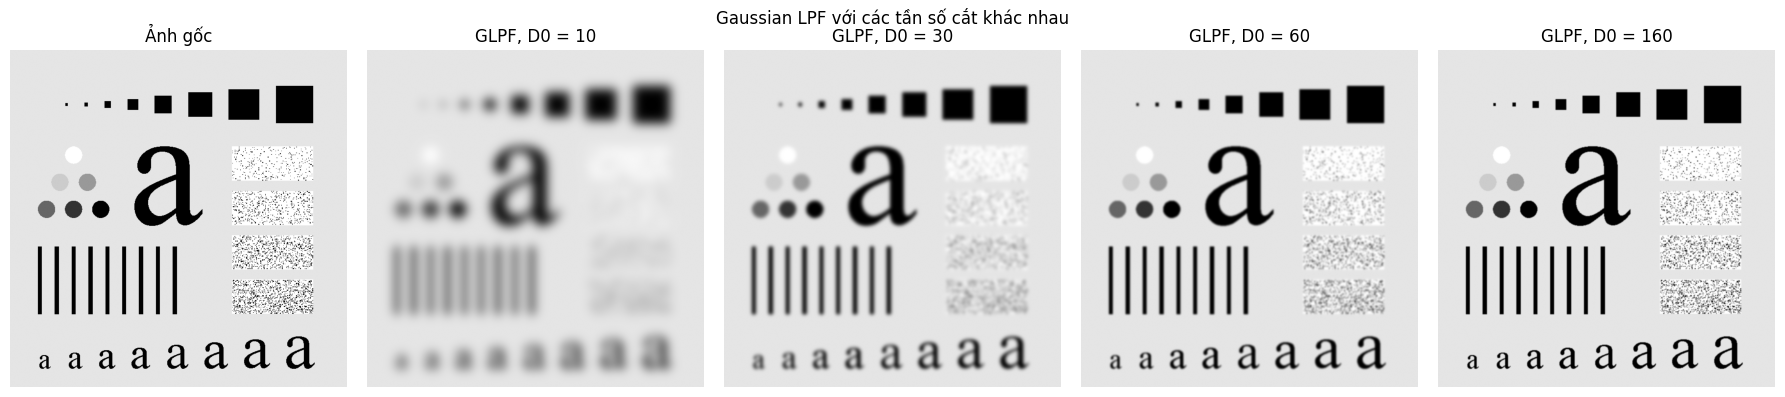

In [3]:
## Ví dụ 3: Ảnh hưởng của tần số cắt D0 (Gaussian LPF)
# D0 càng nhỏ -> càng nhiều tần số cao bị loại -> ảnh càng mờ.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif").convert("L"))
M, N = img.shape
u = np.arange(M) - M // 2; v = np.arange(N) - N // 2
V, U = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))

cutoffs = [10, 30, 60, 160]
fig, axes = plt.subplots(1, len(cutoffs) + 1, figsize=(18, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh gốc"); axes[0].axis("off")
for ax, D0 in zip(axes[1:], cutoffs):
    H = np.exp(-(D**2) / (2.0 * D0**2))
    g = np.clip(np.real(np.fft.ifft2(np.fft.ifftshift(F * H))), 0, 255)
    ax.imshow(g, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"GLPF, D0 = {D0}"); ax.axis("off")
plt.suptitle("Gaussian LPF với các tần số cắt khác nhau")
plt.tight_layout()
plt.show()


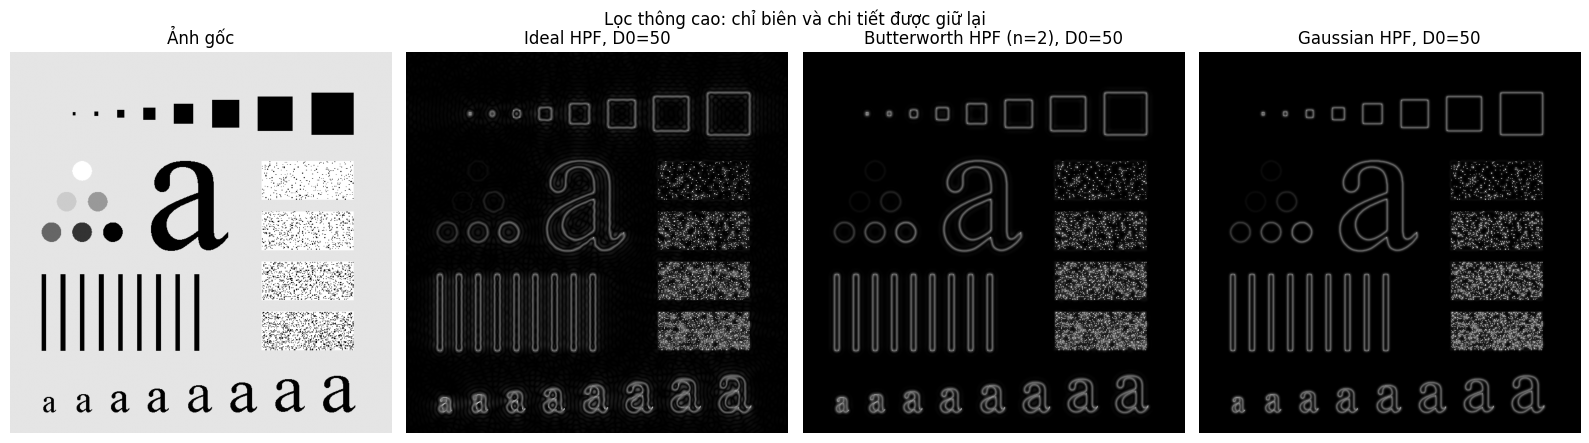

In [4]:
## Ví dụ 4: Lọc thông cao — phát hiện biên/chi tiết trong miền tần số
# Bộ lọc thông cao = 1 - bộ lọc thông thấp tương ứng.
# Chỉ giữ tần số cao -> chỉ còn biên và chi tiết nhỏ.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif").convert("L"))
M, N = img.shape
u = np.arange(M) - M // 2; v = np.arange(N) - N // 2
V, U = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))

D0 = 50
filters = [("Ideal HPF", (D > D0).astype(np.float64)),
           ("Butterworth HPF (n=2)", 1.0 - 1.0 / (1.0 + (D / D0) ** 4)),
           ("Gaussian HPF", 1.0 - np.exp(-(D**2) / (2.0 * D0**2)))]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh gốc"); axes[0].axis("off")
for ax, (t, H) in zip(axes[1:], filters):
    g = np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))
    ax.imshow(np.abs(g), cmap="gray")
    ax.set_title(f"{t}, D0={D0}"); ax.axis("off")
plt.suptitle("Lọc thông cao: chỉ biên và chi tiết được giữ lại")
plt.tight_layout()
plt.show()


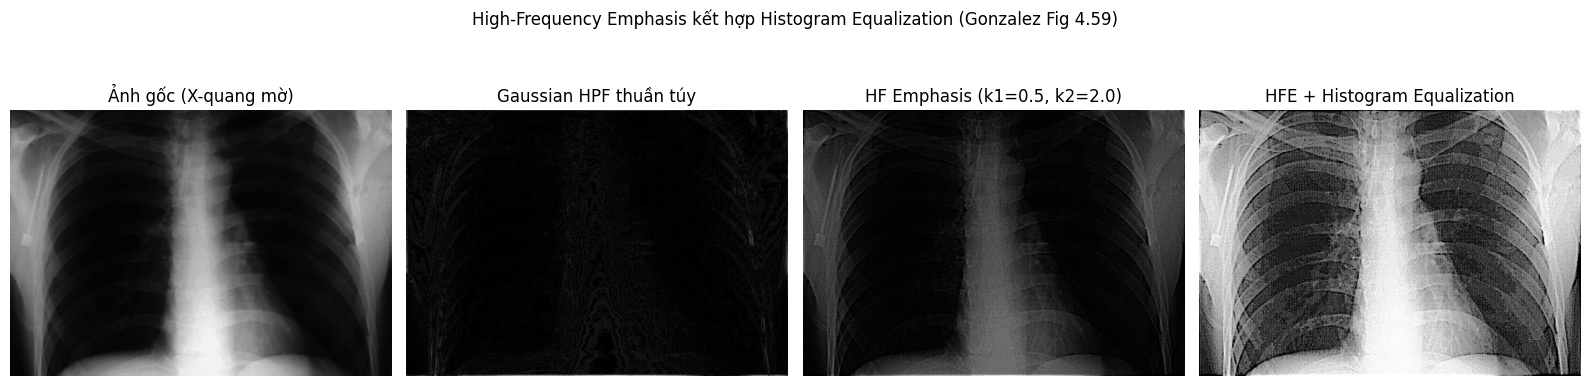

In [5]:
## Ví dụ 5: High-Frequency Emphasis — làm sắc nét ảnh X-quang
# Ứng dụng kinh điển (Gonzalez, Fig 4.59): ảnh X-quang ngực mờ, tương phản thấp.
# g = (k1 + k2 * H_hp) ∘ F  với k1 giữ lại thành phần tần số thấp, k2 khuếch đại tần số cao.
# Sau đó cân bằng histogram để tăng tương phản.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH04/Fig0459(a)(orig_chest_xray).tif").convert("L"))
M, N = img.shape
u = np.arange(M) - M // 2; v = np.arange(N) - N // 2
V, U = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))

D0 = 40
H_hp = 1.0 - np.exp(-(D**2) / (2.0 * D0**2))     # Gaussian highpass

# Chỉ lọc thông cao thuần túy
g_hp = np.real(np.fft.ifft2(np.fft.ifftshift(F * H_hp)))

# High-frequency emphasis: k1 = 0.5, k2 = 2.0
k1, k2 = 0.5, 2.0
H_hfe = k1 + k2 * H_hp
g_hfe = np.clip(np.real(np.fft.ifft2(np.fft.ifftshift(F * H_hfe))), 0, 255).astype(np.uint8)

# Cân bằng histogram sau khi nhấn tần số cao
g_final = cv2.equalizeHist(g_hfe)

titles = ["Ảnh gốc (X-quang mờ)", "Gaussian HPF thuần túy",
          f"HF Emphasis (k1={k1}, k2={k2})", "HFE + Histogram Equalization"]
images = [img, np.abs(g_hp), g_hfe, g_final]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t); ax.axis("off")
plt.suptitle("High-Frequency Emphasis kết hợp Histogram Equalization (Gonzalez Fig 4.59)")
plt.tight_layout()
plt.show()


## 📝 Exercises (en)
1. Apply the three lowpass filters to `Fig0464(a)(car_75DPI_Moire).tif` (CH04) and find the filter/cutoff that best suppresses the moiré pattern.
2. Sharpen `Fig0458(a)(blurry_moon).tif` (CH04) in the frequency domain using the Laplacian: `H(u,v) = -4π²D²(u,v)`, then `g = f - c·∇²f`. Compare with spatial-domain Laplacian from Week 04.
3. Enhance the fingerprint `Fig0457(a)(thumb_print).tif` (CH04) with a Butterworth highpass filter followed by thresholding.
4. Take any image, keep only its **phase** (set magnitude to 1) and reconstruct; then keep only its **magnitude** (set phase to 0). Which carries more structural information?
5. (Optional) Implement zero-padding to size P×Q = 2M×2N before filtering and compare results with the no-padding version (wraparound error).

## 📝 Bài tập (vi)
1. Áp dụng ba bộ lọc thông thấp lên `Fig0464(a)(car_75DPI_Moire).tif` (CH04), tìm bộ lọc/tần số cắt khử vân moiré tốt nhất.
2. Làm sắc nét `Fig0458(a)(blurry_moon).tif` (CH04) trong miền tần số bằng Laplacian: `H(u,v) = -4π²D²(u,v)`, rồi `g = f - c·∇²f`. So sánh với Laplacian miền không gian ở tuần 04.
3. Tăng cường ảnh vân tay `Fig0457(a)(thumb_print).tif` (CH04) bằng Butterworth highpass rồi phân ngưỡng.
4. Lấy một ảnh bất kỳ, chỉ giữ **pha** (đặt biên độ = 1) rồi khôi phục; sau đó chỉ giữ **biên độ** (đặt pha = 0). Thành phần nào mang nhiều thông tin cấu trúc hơn?
5. (Tuỳ chọn) Cài đặt zero-padding lên kích thước P×Q = 2M×2N trước khi lọc và so sánh với bản không padding (lỗi wraparound).